## Import Library

In [21]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud tidak tersedia")

try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    TEXTBLOB_AVAILABLE = False
    print("TextBlob tidak tersedia")

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#1b2838', '#2a475e', '#66c0f4', '#c7d5e0', '#4c6b22', '#a4d007']

print("Semua library berhasil di import!")
print(f"WordCloud : {'done' if WORDCLOUD_AVAILABLE else 'error'}")
print(f"TextBlob : {'done' if TEXTBLOB_AVAILABLE else 'error'}")

Semua library berhasil di import!
WordCloud : done
TextBlob : done


## Preprocessing

In [22]:
CSV_PATH = 'steam_game_reviews.csv'

df_raw = pd.read_csv(CSV_PATH, usecols=['game_name', 'username', 'review'], engine='python', on_bad_lines='skip')

print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris (raw) : {len(df_raw):,}")
print(f"Jumlah kolom : {df_raw.shape[1]}")
print(f"Game unik : {df_raw['game_name'].nunique()}")
print()
df_raw.head(5)

Dataset berhasil dimuat!
Jumlah baris (raw) : 992,153
Jumlah kolom : 3
Game unik : 242



,review,game_name,username
0,The game itself is also super fun. The PvP and the campaign are a joy to play. Your actions feel...,"Warhammer 40,000: Space Marine 2",Sentinowl\n224 products in account
1,Never cared much about Warhammer until this game showed me the error of my ways and made me cast...,"Warhammer 40,000: Space Marine 2",userpig\n248 products in account
2,A salute to all the fallen battle brothers who couldn't be here with us after those 12 years of ...,"Warhammer 40,000: Space Marine 2",Imparat0r\n112 products in account
3,this game feels like it was made in the mid 2000's/early 2010's but like in a good way,"Warhammer 40,000: Space Marine 2",Fattest_falcon
4,Reminds me of something I've lost. A genuine game. A good game. It's simple and short. I love it.,"Warhammer 40,000: Space Marine 2",Jek\n410 products in account


In [23]:
SAMPLE_PER_GAME = 500

df = df_raw.groupby('game_name', group_keys=False).apply(
    lambda g: g.sample(min(len(g), SAMPLE_PER_GAME), random_state=42)
).reset_index(drop=True)

print(f"Setelah stratified sampling (max {SAMPLE_PER_GAME}/game):")
print(f"Jumlah baris : {len(df):,}")
print(f"Game unik : {df['game_name'].nunique()}")
print()
print("Review count per game (top 10) :")
df['game_name'].value_counts().head(10)

Setelah stratified sampling (max 500/game):
Jumlah baris : 117,656
Game unik : 242

Review count per game (top 10) :


,count
game_name,
7 Days to Die,500
ARK: Survival Ascended,500
Ale & Tale Tavern,500
ARK: Survival Evolved,500
Age of Empires II (Retired),500
Age of Empires II: Definitive Edition,500
Age of Empires IV: Anniversary Edition,500
Age of Mythology: Retold,500
Age of Wonders 4,500


## EDA

In [24]:
print("Cek Missing Values (Sebelum)")
print(df.isnull().sum())
print(f"\nTotal missing : {df.isnull().sum().sum()}")

Cek Missing Values (Sebelum)
review       80
game_name     0
username      8
dtype: int64

Total missing : 88


In [25]:
n_before = len(df)

df = df.dropna(subset=['review'])
n_after_na = len(df)
print(f"[1] Hapus missing review : -{n_before - n_after_na:,} baris")

df['review'] = df['review'].astype(str)
df['game_name'] = df['game_name'].astype(str)
df['username'] = df['username'].astype(str)

df_no_dup = df.drop_duplicates(subset=['game_name', 'review'])
n_after_dup = len(df_no_dup)
print(f"[2] Hapus duplikat review : -{n_after_na - n_after_dup:,} baris")
df = df_no_dup.copy()

print(f"\n Dataset bersih: {len(df):,} baris tersisa dari {n_before:,}")
print(f"({len(df)/n_before*100:.1f}% data retained)")

[1] Hapus missing review : -80 baris
[2] Hapus duplikat review : -1,243 baris

 Dataset bersih: 116,333 baris tersisa dari 117,656
(98.9% data retained)


In [26]:
def clean_text_vectorized(series: pd.Series) -> pd.Series:
    s = series.str.lower()
    s = s.str.replace(r'https?://\S+|www\.\S+', '', regex=True)
    s = s.str.replace(r'<[^>]+>', '', regex=True)
    s = s.str.replace(r'[^a-z\s]', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    return s

df['review_clean'] = clean_text_vectorized(df['review'])

df = df[df['review_clean'].str.len() > 10]

print("Contoh Sebelum vs Sesudah Normalisasi")
for i in [0, 1, 2]:
    row = df.iloc[i]
    print(f"\n[{i+1}] Game : {row['game_name']}")
    print(f"BEFORE : {row['review'][:120]}")
    print(f"AFTER : {row['review_clean'][:120]}")

print(f"\n Dataset final setelah normalisasi: {len(df):,} baris")

Contoh Sebelum vs Sesudah Normalisasi

[1] Game : 69 Balls
BEFORE : Best Game Ever
AFTER : best game ever

[2] Game : 69 Balls
BEFORE : I love 69 balls it might just be one of the best games on steam 10/10
AFTER : i love balls it might just be one of the best games on steam

[3] Game : 69 Balls
BEFORE : 2023 rocket league if it had good mobility
AFTER : rocket league if it had good mobility

 Dataset final setelah normalisasi: 105,440 baris


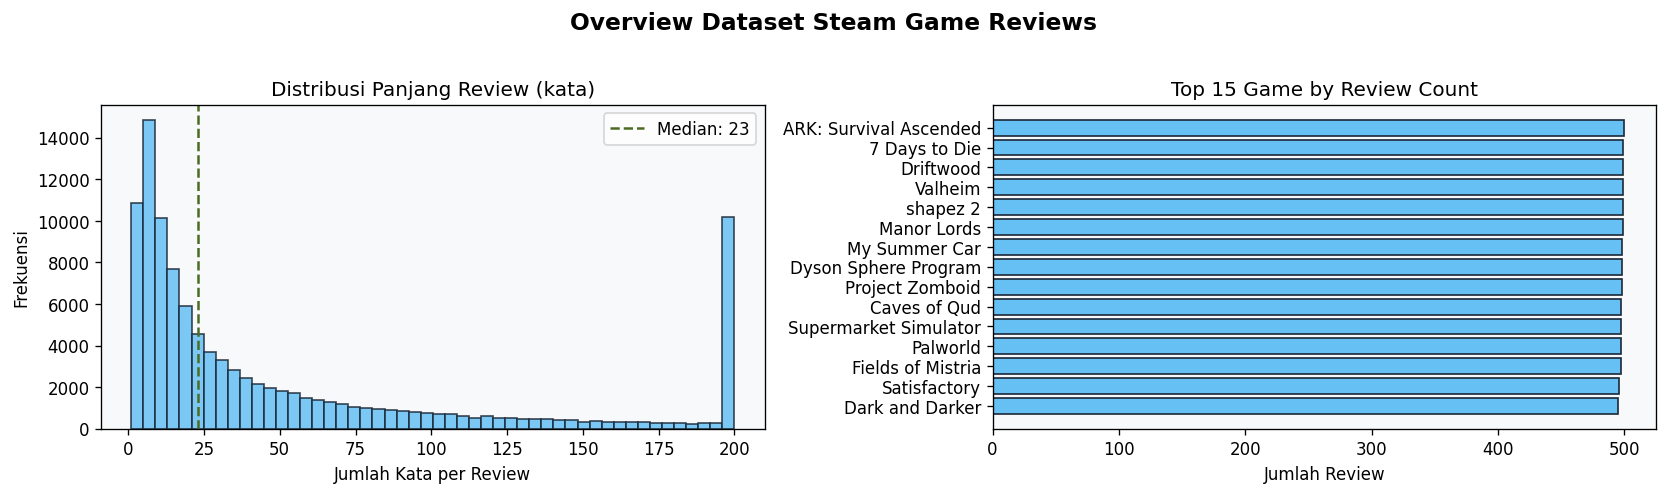

In [27]:
df['review_length'] = df['review_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['review_length'].clip(upper=200), bins=50,
             color=PALETTE[2], edgecolor=PALETTE[0], alpha=0.85)
axes[0].set_xlabel('Jumlah Kata per Review')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Panjang Review (kata)')
axes[0].axvline(df['review_length'].median(), color=PALETTE[4],
                linestyle='--', label=f"Median: {df['review_length'].median():.0f}")
axes[0].legend()
axes[0].set_facecolor('#f8f9fa')

top_games = df['game_name'].value_counts().head(15)
axes[1].barh(top_games.index[::-1], top_games.values[::-1],
             color=PALETTE[2], edgecolor=PALETTE[0])
axes[1].set_xlabel('Jumlah Review')
axes[1].set_title('Top 15 Game by Review Count')
axes[1].set_facecolor('#f8f9fa')

plt.suptitle('Overview Dataset Steam Game Reviews', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Tokenization

In [48]:
def tokenize(text: str) -> list:
    return re.findall(r'\b[a-z]{3,}\b', text)

sample_review = df['review_clean'].iloc[0]
tokens = tokenize(sample_review)

print("Contoh Tokenization")
print(f"Teks : {sample_review[:150]}")
print(f"Token : {tokens[:20]}")
print(f"Total token : {len(tokens)}")
print()

all_tokens_sample = df['review_clean'].head(1000).apply(tokenize).explode()
print("Token Terbanyak (tanpa stopword removal, top 20)")
print(Counter(all_tokens_sample).most_common(20))

Contoh Tokenization
Teks : best game ever
Token : ['best', 'game', 'ever']
Total token : 3

Token Terbanyak (tanpa stopword removal, top 20)
[('the', 4402), ('and', 3008), ('game', 2167), ('you', 1640), ('balls', 1483), ('this', 1356), ('for', 1050), ('that', 1046), ('early', 981), ('access', 974), ('review', 968), ('with', 933), ('but', 764), ('have', 761), ('are', 642), ('can', 603), ('not', 528), ('they', 489), ('your', 454), ('like', 438)]


## Implementasi TF-IDF + IDF Threshold

In [29]:
game_docs = (
    df.groupby('game_name')['review_clean']
      .apply(lambda x: ' '.join(x))
      .reset_index()
)
game_docs.columns = ['game_name', 'combined_review']

print(f"Total dokumen (game) : {len(game_docs)}")
print(f"Avg panjang dokumen : {game_docs['combined_review'].str.len().mean():,.0f} karakter")
game_docs.head(5)

Total dokumen (game) : 242
Avg panjang dokumen : 175,661 karakter


,game_name,combined_review
0,69 Balls,best game ever i love balls it might just be one of the best games on steam rocket league if it ...
1,7 Days to Die,early access review best game ever it has everything zombies crafting building shooting quests c...
2,ARK: Survival Ascended,early access review what a show early access review good game early access review i ll recommend...
3,ARK: Survival Evolved,very good very nice early access review really amazing game only if u can load in a server produ...
4,Age of Empires II (Retired),wew buy great with friends strategy game for nerds d we are all nerds i m at a loss for words th...


In [49]:
vectorizer = TfidfVectorizer(
    token_pattern=r'\b[a-z]{3,}\b',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=25000,
    smooth_idf=True,
    sublinear_tf=True,
)

print("Fitting TF-IDF")
tfidf_matrix = vectorizer.fit_transform(game_docs['combined_review'])
feature_names = vectorizer.get_feature_names_out()
idf_values    = vectorizer.idf_

print(f"\n TF-IDF selesai")
print(f"Matrix shape : {tfidf_matrix.shape} (games × terms)")
print(f"Ukuran vocabulary : {len(feature_names):,} terms")
print(f"IDF min : {idf_values.min():.4f}")
print(f"IDF max : {idf_values.max():.4f}")
print(f"IDF mean : {idf_values.mean():.4f}")

Fitting TF-IDF

 TF-IDF selesai
Matrix shape : (242, 25000) (games × terms)
Ukuran vocabulary : 25,000 terms
IDF min : 1.1652
IDF max : 5.3944
IDF mean : 2.5285


In [31]:
IDF_THRESHOLD_PERCENTILE = 20
IDF_THRESHOLD = float(np.percentile(idf_values, IDF_THRESHOLD_PERCENTILE))

print(f"IDF Threshold (persentil ke-{IDF_THRESHOLD_PERCENTILE}): {IDF_THRESHOLD:.4f}")
print(f"Kata dengan IDF < {IDF_THRESHOLD:.4f} dianggap STOPWORD/UMUM")
print()

is_common = idf_values < IDF_THRESHOLD
common_words  = feature_names[is_common]
distinct_words = feature_names[~is_common]

print(f"Kata 'umum' yang dibuang ({len(common_words):,} terms):")
print(f"{list(common_words[:30])}")
print()
print(f"Kata 'khusus' yang dipertahankan ({len(distinct_words):,} terms):")
print(f"{list(distinct_words[:30])}")

IDF Threshold (persentil ke-20): 1.9498
Kata dengan IDF < 1.9498 dianggap STOPWORD/UMUM

Kata 'umum' yang dibuang (4,957 terms):
['aaa', 'abandoned', 'abilities', 'able get', 'able play', 'about and', 'about hours', 'about how', 'about leaderboards', 'about that', 'about their', 'about what', 'about you', 'absolutely amazing', 'absolutely love', 'absurd', 'accept', 'acceptable', 'access the', 'accessible', 'accidentally', 'according', 'account', 'accurate', 'achieve', 'achieved', 'achievement', 'achievements', 'across the', 'act']

Kata 'khusus' yang dipertahankan (20,043 terms):
['aaa game', 'aaa games', 'aaa title', 'aaa titles', 'abandon', 'abilities and', 'abilities are', 'abilities that', 'abilities the', 'abilities you', 'ability and', 'ability create', 'ability for', 'ability make', 'ability play', 'abit', 'able build', 'able change', 'able experience', 'able have', 'able make', 'able put', 'able run', 'able see', 'able use', 'about all', 'about any', 'about anything', 'about be

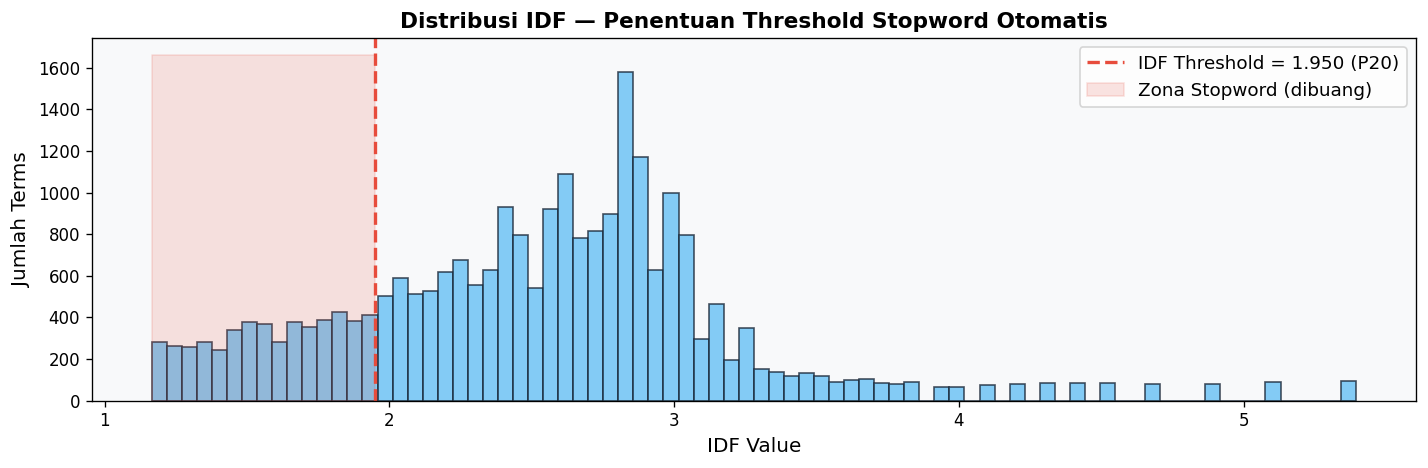

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(idf_values, bins=80, color=PALETTE[2], edgecolor=PALETTE[0], alpha=0.8)
ax.axvline(IDF_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'IDF Threshold = {IDF_THRESHOLD:.3f} (P{IDF_THRESHOLD_PERCENTILE})')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1000],
                  idf_values.min(), IDF_THRESHOLD,
                  color='#e74c3c', alpha=0.15, label='Zona Stopword (dibuang)')

ax.set_xlabel('IDF Value', fontsize=12)
ax.set_ylabel('Jumlah Terms', fontsize=12)
ax.set_title('Distribusi IDF — Penentuan Threshold Stopword Otomatis', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## Ekstraksi Signature Keywords


In [50]:
N_KEYWORDS = 3

results = []
for i in range(len(game_docs)):
    game = game_docs.iloc[i]['game_name']

    scores = tfidf_matrix[i].toarray().flatten()

    filtered_scores = scores.copy()
    filtered_scores[idf_values < IDF_THRESHOLD] = 0

    top_idx = filtered_scores.argsort()[-N_KEYWORDS:][::-1]
    keywords = [
        feature_names[j]
        for j in top_idx
        if filtered_scores[j] > 0
    ]

    top_scores = [round(float(filtered_scores[j]), 6) for j in top_idx if filtered_scores[j] > 0]

    results.append({
        'game_name'         : game,
        'signature_keywords': ', '.join(keywords[:N_KEYWORDS]),
        'keyword_scores'    : top_scores[:N_KEYWORDS],
    })

sig_df = pd.DataFrame(results)
print(f"Signature keywords berhasil diekstrak untuk {len(sig_df)} game")
print()
print(sig_df[['game_name', 'signature_keywords']].to_string(index=False))

Signature keywords berhasil diekstrak untuk 242 game

                                          game_name                            signature_keywords
                                           69 Balls        balls balls, rocket league, league but
                                      7 Days to Die            days die, zombies are, the zombies
                             ARK: Survival Ascended                           nitrado, ase, dinos
                              ARK: Survival Evolved                       dinos, wildcard, taming
                        Age of Empires II (Retired)                     age empires, empires, rts
              Age of Empires II: Definitive Edition         definitive edition, age empires, civs
             Age of Empires IV: Anniversary Edition                        civs, age empires, aoe
                           Age of Mythology: Retold                    aom, retold, age mythology
                                   Age of Wonders 4             

In [34]:
df_final = df.merge(
    sig_df[['game_name', 'signature_keywords']],
    on='game_name',
    how='left'
)

print("Kolom Dataset Final")
print(df_final.columns.tolist())
print()
print(df_final[['game_name', 'username', 'review_clean', 'signature_keywords']].head(10).to_string())

Kolom Dataset Final
['review', 'game_name', 'username', 'review_clean', 'review_length', 'signature_keywords']

  game_name                              username                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

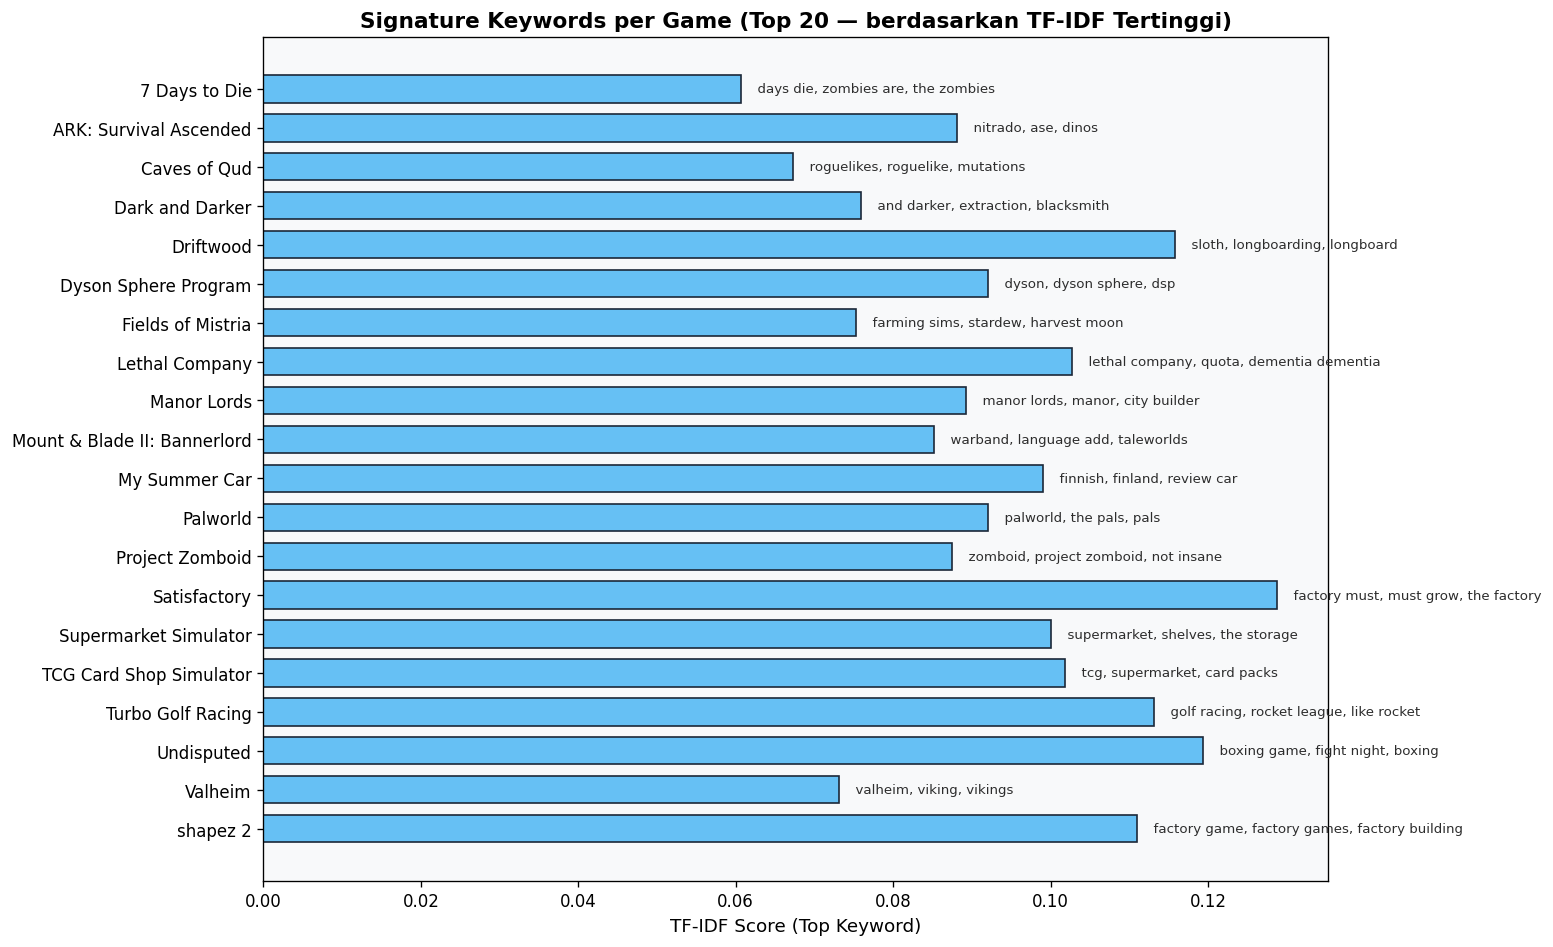

In [35]:
top20_games = df['game_name'].value_counts().head(20).index.tolist()
sig_top20   = sig_df[sig_df['game_name'].isin(top20_games)].copy()
sig_top20['top_score'] = sig_top20['keyword_scores'].apply(
    lambda x: x[0] if x else 0
)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    sig_top20['game_name'],
    sig_top20['top_score'],
    color=PALETTE[2],
    edgecolor=PALETTE[0],
    height=0.7
)

for bar, (_, row) in zip(bars, sig_top20.iterrows()):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"  {row['signature_keywords']}",
        va='center', ha='left', fontsize=8, color='#2d2d2d'
    )

ax.set_xlabel('TF-IDF Score (Top Keyword)', fontsize=11)
ax.set_title('Signature Keywords per Game (Top 20 — berdasarkan TF-IDF Tertinggi)',
             fontsize=13, fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## BONUS 1 — Sentiment Analysis per Game (TextBlob)

In [36]:
if TEXTBLOB_AVAILABLE:
    print("Menghitung sentiment per game")

    def get_sentiment(text: str) -> dict:
        blob = TextBlob(text[:5000])
        return {
            'polarity'    : blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }

    sentiment_records = []
    for _, row in game_docs.iterrows():
        s = get_sentiment(row['combined_review'])
        sentiment_records.append({
            'game_name'   : row['game_name'],
            'polarity'    : s['polarity'],
            'subjectivity': s['subjectivity'],
        })

    sent_df = pd.DataFrame(sentiment_records)


    sent_df['sentiment_label'] = pd.cut(
        sent_df['polarity'],
        bins=[-1.01, -0.05, 0.05, 1.01],
        labels=['Negatif', 'Netral', 'Positif']
    )

    print("\n Distribusi Sentimen Game")
    print(sent_df['sentiment_label'].value_counts())
    print()

    sig_df = sig_df.merge(sent_df, on='game_name', how='left')

    print("Game dengan review paling POSITIF:")
    print(sig_df.nlargest(5, 'polarity')[['game_name','signature_keywords','polarity']].to_string(index=False))
    print()
    print("Game dengan review paling NEGATIF:")
    print(sig_df.nsmallest(5, 'polarity')[['game_name','signature_keywords','polarity']].to_string(index=False))
else:
    print("TextBlob tidak tersedia")
    print("Install dengan: pip install textblob")

Menghitung sentiment per game

 Distribusi Sentimen Game
sentiment_label
Positif    175
Netral      63
Negatif      4
Name: count, dtype: int64

Game dengan review paling POSITIF:
       game_name                      signature_keywords  polarity
           Stray                    meow meow, mew, meow  0.259014
Wallpaper Engine wallpapers, wallpaper engine, wallpaper  0.257251
         Aimlabs          shoot shoot, your aim, trainer  0.242532
   Assetto Corsa           assetto, kunos, assetto corsa  0.233301
        Portal 2                 glados, portal, portals  0.231380

Game dengan review paling NEGATIF:
       game_name             signature_keywords  polarity
EA SPORTS FC™ 24  fifa, football game, football -0.147170
Dead by Daylight dead daylight, dbd, the killer -0.090860
        NBA 2K24      mycareer, nba, basketball -0.066903
      eFootball™         pes, efootball, konami -0.054019
 Team Fortress 2     team fortress, ducks, hank -0.047911


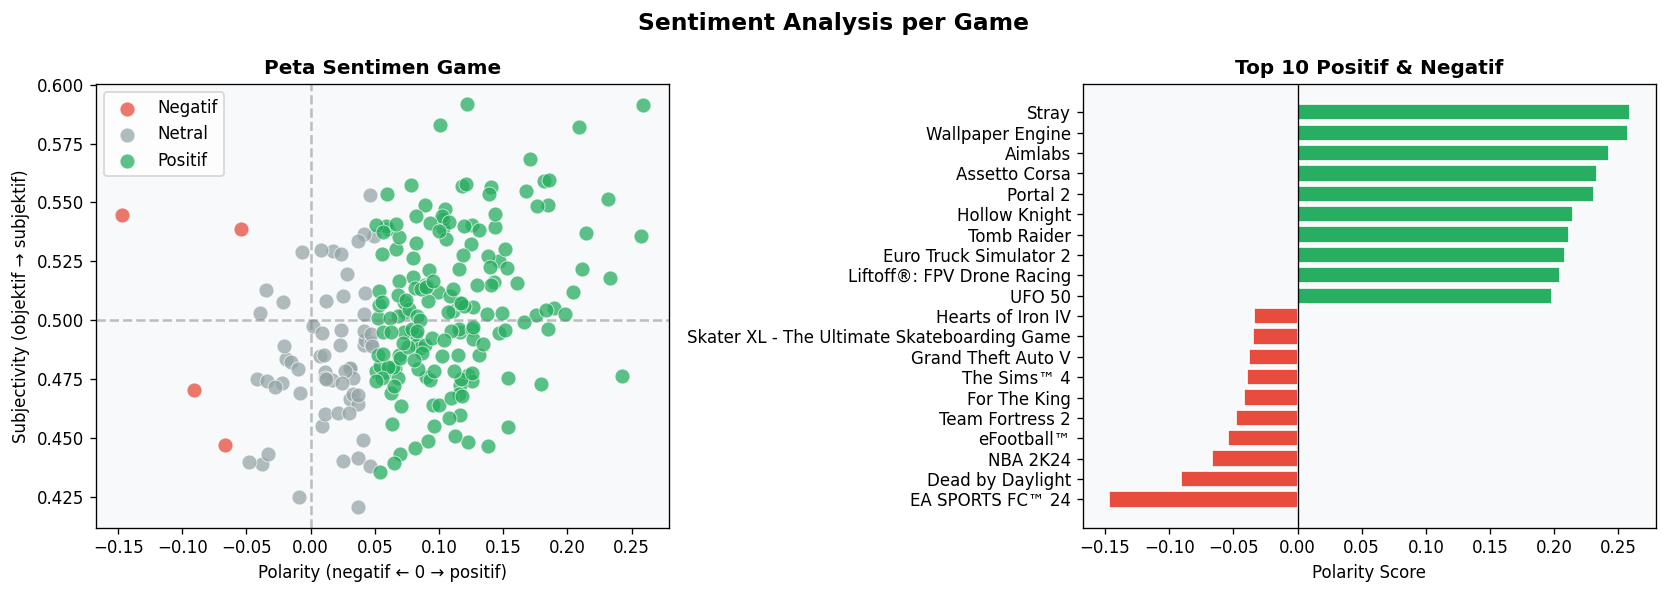

In [37]:
if TEXTBLOB_AVAILABLE and 'polarity' in sig_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    color_map = {'Positif': '#27ae60', 'Netral': '#95a5a6', 'Negatif': '#e74c3c'}
    for label, group in sig_df.groupby('sentiment_label'):
        axes[0].scatter(
            group['polarity'], group['subjectivity'],
            label=label, color=color_map[str(label)],
            alpha=0.75, s=80, edgecolors='white', linewidth=0.5
        )
    axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Polarity (negatif ← 0 → positif)')
    axes[0].set_ylabel('Subjectivity (objektif → subjektif)')
    axes[0].set_title('Peta Sentimen Game', fontweight='bold')
    axes[0].legend()
    axes[0].set_facecolor('#f8f9fa')

    top10 = sig_df.nlargest(10, 'polarity')
    bot10 = sig_df.nsmallest(10, 'polarity')
    combined = pd.concat([top10, bot10]).sort_values('polarity')
    colors = ['#e74c3c' if p < 0 else '#27ae60' for p in combined['polarity']]
    axes[1].barh(combined['game_name'], combined['polarity'], color=colors, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Polarity Score')
    axes[1].set_title('Top 10 Positif & Negatif', fontweight='bold')
    axes[1].set_facecolor('#f8f9fa')

    plt.suptitle('Sentiment Analysis per Game', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## BONUS 2 — WordCloud per Game

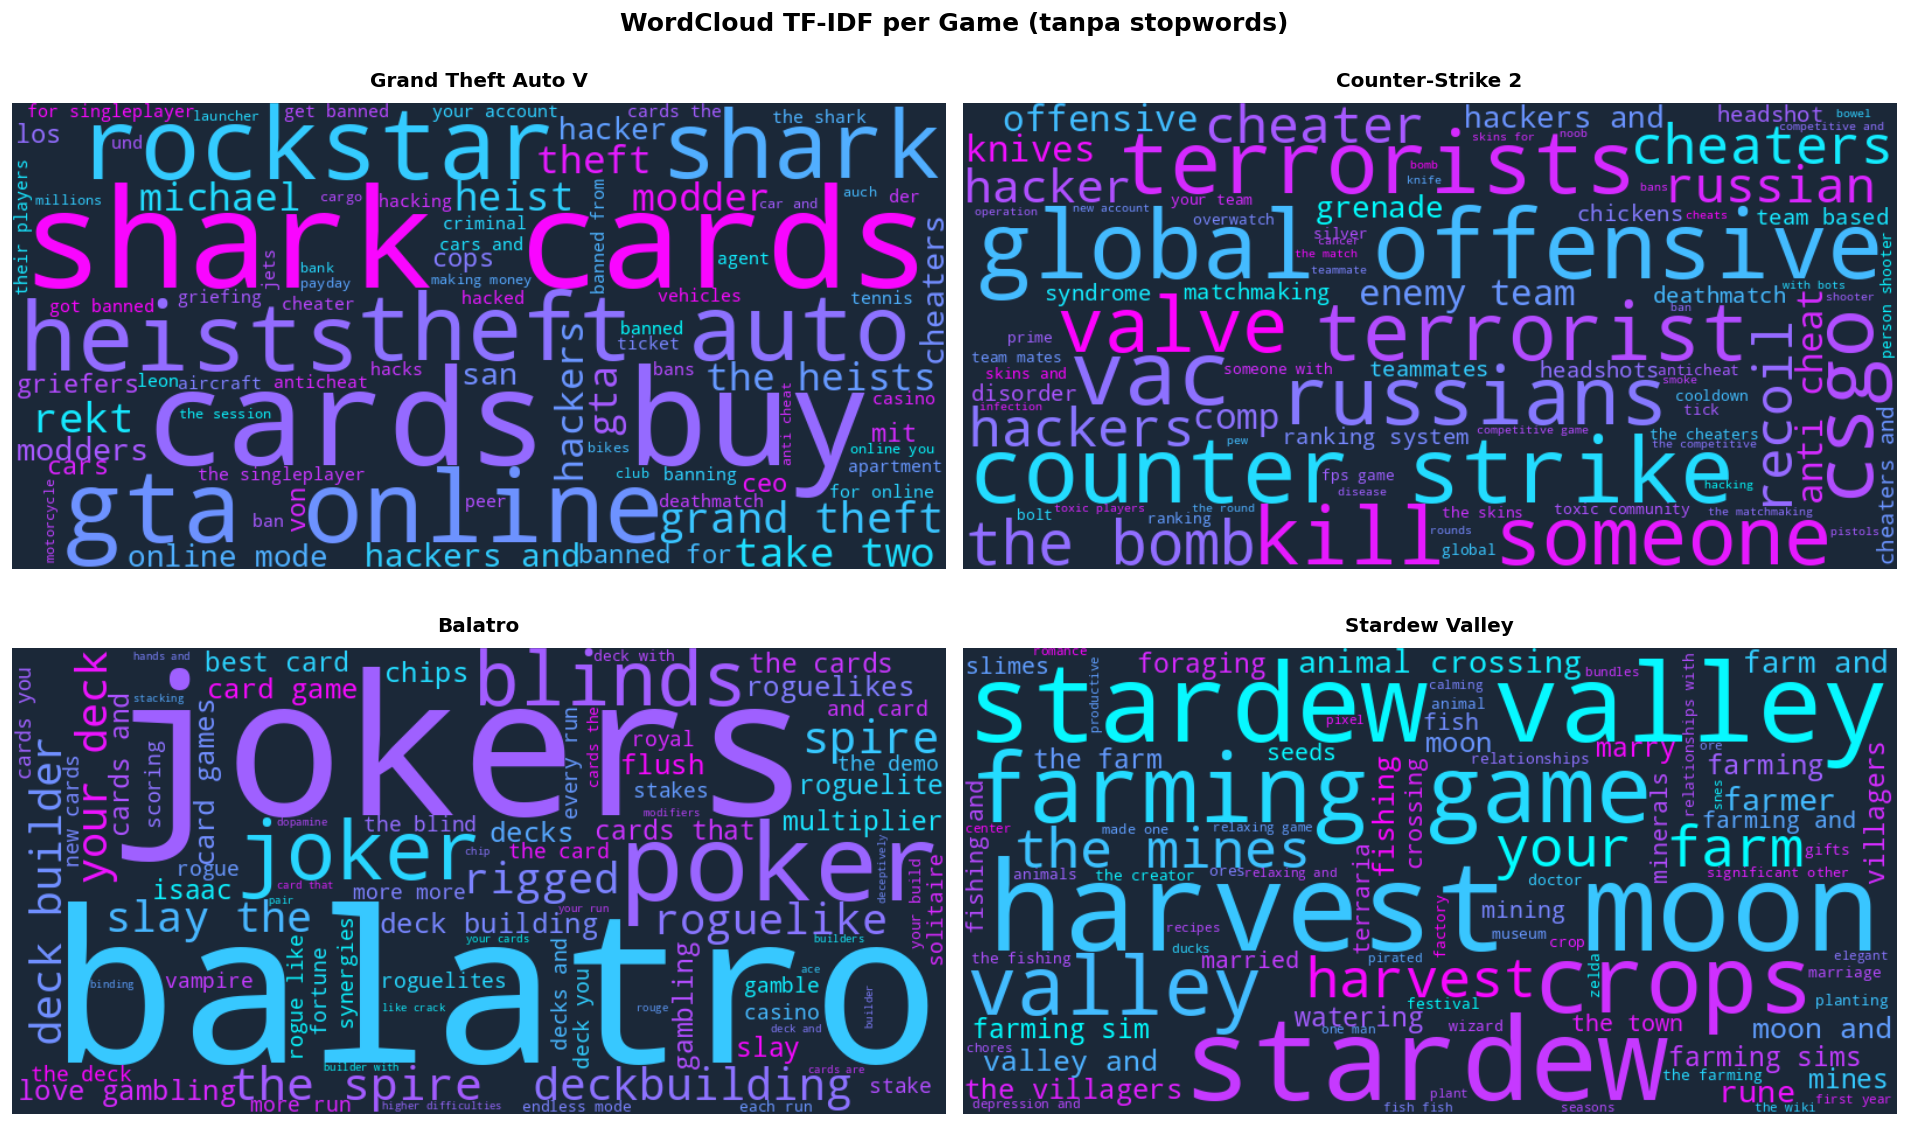

In [47]:
if WORDCLOUD_AVAILABLE:
    TOP_GAMES_FOR_WC = [
        'Grand Theft Auto V',
        'Counter-Strike 2',
        'Balatro',
        'Stardew Valley',
    ]

    available = game_docs['game_name'].tolist()
    wc_games = [g for g in TOP_GAMES_FOR_WC if g in available]
    if not wc_games:
        wc_games = game_docs['game_name'].iloc[:4].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, game in zip(axes, wc_games):
        idx = game_docs[game_docs['game_name'] == game].index[0]
        scores = tfidf_matrix[idx].toarray().flatten()
        scores[idf_values < IDF_THRESHOLD] = 0

        word_freq = {
            feature_names[i]: float(scores[i])
            for i in np.where(scores > 0)[0]
        }

        if word_freq:
            wc = WordCloud(
                width=800, height=400,
                background_color='#1b2838',
                colormap='cool',
                max_words=80,
                collocations=False
            ).generate_from_frequencies(word_freq)
            ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{game}', fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')

    plt.suptitle('WordCloud TF-IDF per Game (tanpa stopwords)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

## BONUS 3 — Heatmap: Keyword Sharing antar Game


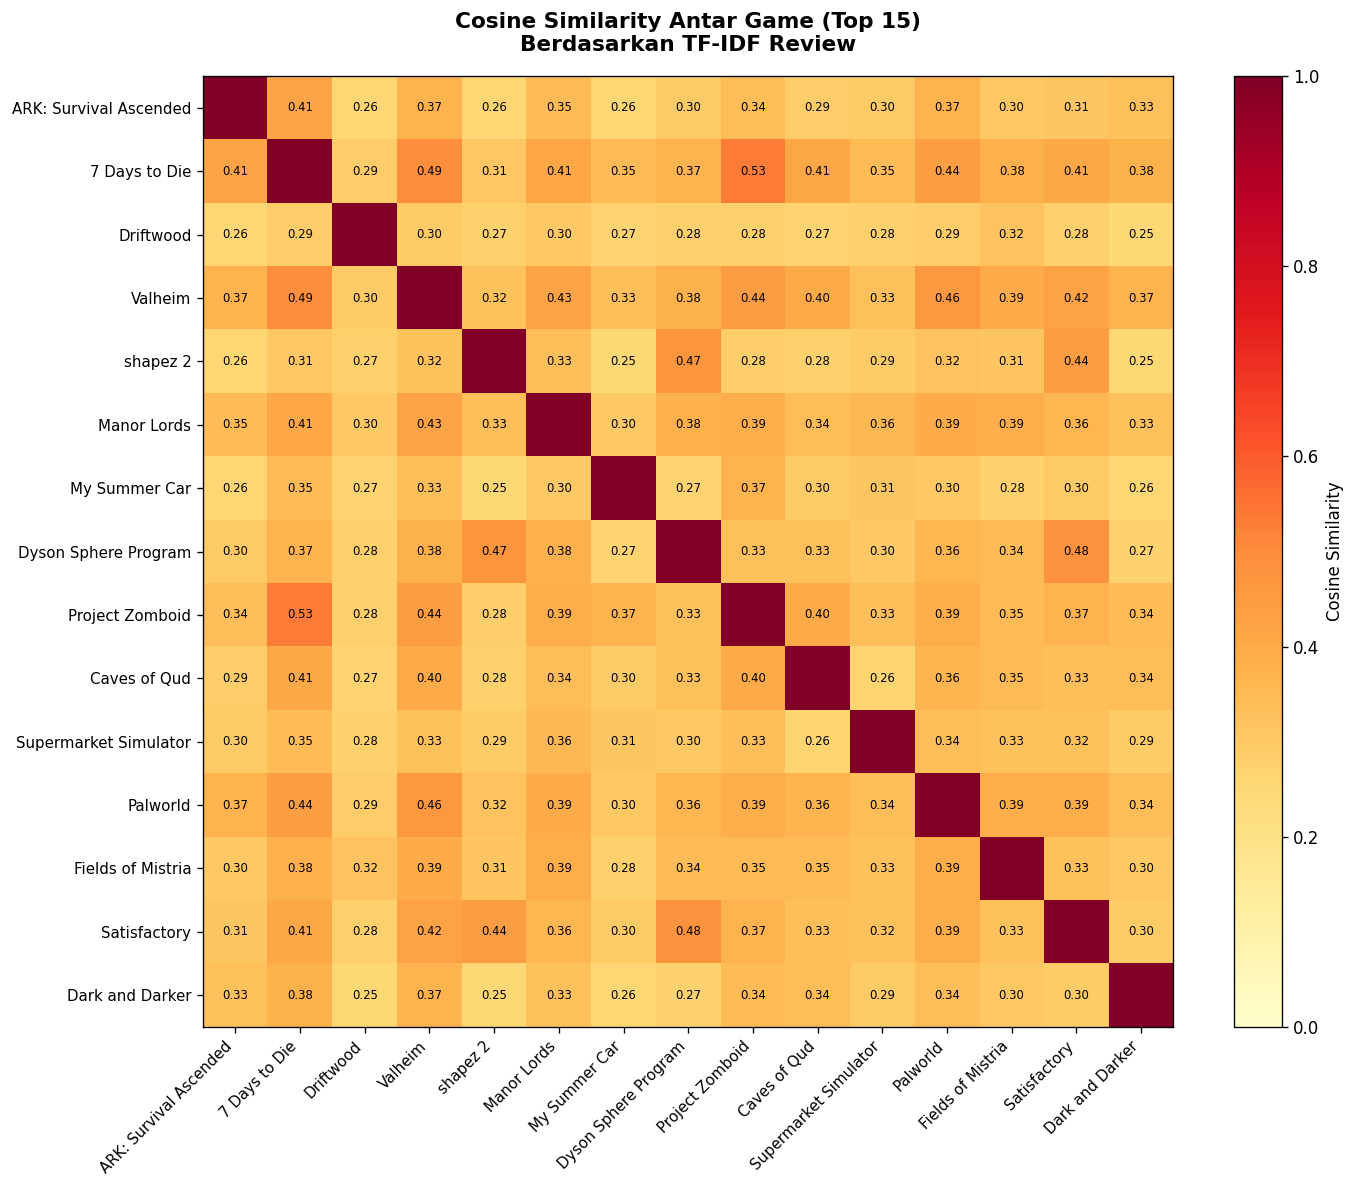

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

TOP_N_HEATMAP = 15

top_n_games = df['game_name'].value_counts().head(TOP_N_HEATMAP).index.tolist()
top_idx_list = [game_docs[game_docs['game_name'] == g].index[0] for g in top_n_games]

sub_matrix = tfidf_matrix[top_idx_list]
sim_matrix = cosine_similarity(sub_matrix)

fig, ax = plt.subplots(figsize=(12, 10))

short_names = [g[:25] + '...' if len(g) > 25 else g for g in top_n_games]

im = ax.imshow(sim_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(TOP_N_HEATMAP))
ax.set_yticks(range(TOP_N_HEATMAP))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

for i in range(TOP_N_HEATMAP):
    for j in range(TOP_N_HEATMAP):
        if i != j:
            ax.text(j, i, f'{sim_matrix[i,j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    color='black' if sim_matrix[i,j] < 0.6 else 'white')

ax.set_title(f'Cosine Similarity Antar Game (Top {TOP_N_HEATMAP})\nBerdasarkan TF-IDF Review',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Export Hasil

In [40]:
output_cols = ['game_name', 'username', 'review', 'review_clean', 'signature_keywords']
df_export = df_final[output_cols].copy()
df_export.to_csv('steam_reviews_with_keywords.csv', index=False)
print(f"Disimpan: steam_reviews_with_keywords.csv ({len(df_export):,} baris)")

if 'polarity' in sig_df.columns:
    export_cols = ['game_name', 'signature_keywords', 'polarity', 'subjectivity', 'sentiment_label']
else:
    export_cols = ['game_name', 'signature_keywords']

sig_df[export_cols].to_csv('game_signature_keywords.csv', index=False)
print(f"Disimpan: game_signature_keywords.csv ({len(sig_df)} game)")

print()
print("Hasil Akhir: Signature Keywords per Game")
pd.set_option('display.max_rows', 242)
print(sig_df[['game_name', 'signature_keywords']].to_string(index=False))

Disimpan: steam_reviews_with_keywords.csv (105,440 baris)
Disimpan: game_signature_keywords.csv (242 game)

Hasil Akhir: Signature Keywords per Game
                                          game_name                            signature_keywords
                                           69 Balls        balls balls, rocket league, league but
                                      7 Days to Die            days die, zombies are, the zombies
                             ARK: Survival Ascended                           nitrado, ase, dinos
                              ARK: Survival Evolved                       dinos, wildcard, taming
                        Age of Empires II (Retired)                     age empires, empires, rts
              Age of Empires II: Definitive Edition         definitive edition, age empires, civs
             Age of Empires IV: Anniversary Edition                        civs, age empires, aoe
                           Age of Mythology: Retold                